# Notebook 24 — PDO Window Test + Snow Cover + Orientation-Invariant Features

Three targeted follow-ups from nb22 open questions:

**Part A — PDO window-length test:** Finding 60 showed PDO at 60-month windows lands in the sea_level cluster (cl4), not the ENSO cluster (cl8). Hypothesis: at 36-month windows (same as ENSO ONI), PDO's oscillatory character becomes visible and it migrates to cl8.

**Part B — Declining oscillator outside the cryosphere:** Arctic and Antarctic sea ice are the only confirmed cl0 members. NH Snow Cover Extent (Rutgers University, 1967–present) has a strong annual cycle and documented long-term spring decline. Does it join cl0?

**Part C — Orientation-invariant 6-feature fingerprint:** nb23 showed the 6-feature space is direction-sensitive (amplitude-flip causes 100% boundary crossing for trend/seasonal/declining_osc). Chronos is NOT direction-sensitive (Finding 52). Adding |slope| and |baseline_delta| makes the fingerprint orientation-invariant. Do directionally-defined classes collapse into their time-reversed counterparts? Do the 8 classes become fewer?

---

## Pre-run Predictions

| Test | Prediction | Reasoning |
|---|---|---|
| PDO at 36-month windows | Migrates toward cl8 (ENSO region) | Oscillatory cycle fits in window; same Pacific basin dynamics become visible |
| NH Snow Cover | Joins cl0 (Arctic/Antarctic) | Strong annual cycle + long-term spring decline = declining oscillator structure |
| |slope| + |baseline_delta| added | Trend and reversed-trend collapse; seasonal and reversed-seasonal collapse; 8 classes reduce to ~5–6 | Direction-defined classes lose their defining asymmetry; shape-defined classes unchanged |

In [2]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from chronos import ChronosPipeline
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
TIMEDOM_INV  = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope_abs', 'baseline_delta_abs']
TARGET_LEN = 64

print(f'PyTorch {torch.__version__}')

PyTorch 2.11.0+cu130


In [4]:
# ============================================================
# HELPERS (identical to nb22)
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()

def baseline_delta(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))

def spectral_features_fixed(series):
    s = zscore_normalize(np.asarray(series, dtype=float))
    n = len(s)
    fft_vals = np.fft.rfft(s)
    power    = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(n)
    power_ac = power[1:]
    freqs_ac = freqs[1:]
    total_ac = power_ac.sum() if power_ac.sum() > 0 else 1.0
    dom_freq = float(freqs[np.argmax(power)])
    p_norm = power_ac / total_ac
    p_norm = p_norm[p_norm > 0]
    sp_ent = float(-np.sum(p_norm * np.log(p_norm)))
    sp_ent /= np.log(len(power_ac)) if len(power_ac) > 1 else 1.0
    n_ac   = len(freqs_ac)
    low_end = int(n_ac * 0.20)
    mid_end = int(n_ac * 0.60)
    return {
        'dominant_freq':    dom_freq,
        'spectral_entropy': sp_ent,
        'power_low':  float(power_ac[:low_end].sum()  / total_ac),
        'power_mid':  float(power_ac[low_end:mid_end].sum() / total_ac),
        'power_high': float(power_ac[mid_end:].sum()  / total_ac),
    }

def extract_all_features(series):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n, t = len(arr), np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    td = {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': float(np.sum(np.diff(np.sign(arr)) != 0) / n),
        'slope':          float(stats.linregress(t, arr).slope),
        'baseline_delta': baseline_delta(arr),
    }
    return {**td, **spectral_features_fixed(arr)}

def resample_series(series, target_length=TARGET_LEN):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n = len(arr)
    if n == target_length:
        return arr
    x_old = np.linspace(0, 1, n)
    x_new = np.linspace(0, 1, target_length)
    return interp1d(x_old, arr, kind='linear')(x_new)

_empty_raw = np.zeros((0, TARGET_LEN))
for _v in ['df_covid_all','df_ss_all','df_lh_all','df_k_all','df_temp_all',
           'df_ecg_all','df_sf_all','df_sl_all','df_oni_all','df_vix_all',
           'df_ch4_all','df_ohc_all','df_ice_all',
           'df_ant_all','df_nao_all','df_pdo_all',
           'df_pdo36_all','df_snow_all']:
    globals()[_v] = pd.DataFrame()
for _v in ['raw_covid','raw_ss','raw_lh','raw_k','raw_temp',
           'raw_ecg','raw_sf','raw_sl','raw_oni','raw_vix',
           'raw_ch4','raw_ohc','raw_ice',
           'raw_ant','raw_nao','raw_pdo',
           'raw_pdo36','raw_snow']:
    globals()[_v] = _empty_raw.copy()
del _v, _empty_raw
print('Helpers OK')

Helpers OK


In [15]:
# ============================================================
# DATASET 1: COVID (first + second wave)
# ============================================================
dest = RAW_DIR / 'owid_covid.csv'
if not dest.exists():
    r = requests.get('https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv', stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
df_raw = pd.read_csv(dest, usecols=['location','date','new_cases_smoothed_per_million','continent'], parse_dates=['date'])
df_covid = df_raw.dropna(subset=['continent']).rename(columns={'new_cases_smoothed_per_million':'cases_pm'})

def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if not len(starts): return None
    start = starts[0]
    wave = s[start:min(start+max_days, len(s))]
    if len(wave) < min_days: return None
    peaks, _ = find_peaks(wave, prominence=wave.max()*0.2)
    if not len(peaks): return None
    wave = wave[:min(peaks[0]+60, len(wave))]
    return wave if len(wave) >= min_days else None

def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max()*0.15, distance=45)
    if len(peaks) < 2: return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    wave = s[start:min(peaks[1]+60, len(s))]
    return wave if len(wave) >= min_days else None

records, raw_series = [], []
for country, grp in df_covid.groupby('location'):
    grp = grp.sort_values('date')
    for fn, ds in [(extract_first_wave,'covid_first_wave'), (extract_second_wave,'covid_second_wave')]:
        w = fn(grp['cases_pm'])
        if w is not None:
            feats = extract_all_features(w)
            feats.update({'country': country, 'dataset': ds, 'n_points': len(w)})
            records.append(feats)
            raw_series.append(resample_series(w))
df_covid_all = pd.DataFrame(records)
raw_covid = np.stack(raw_series)
print(df_covid_all['dataset'].value_counts().to_dict(), f'  raw shape: {raw_covid.shape}')

{'covid_second_wave': 209, 'covid_first_wave': 202}   raw shape: (411, 64)


In [16]:
# ============================================================
# DATASET 2: Sunspot cycles
# ============================================================
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv').content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
minima, _ = find_peaks(-smoothed, distance=80)
cycles = {}
for i in range(len(minima)-1):
    c = series_full[minima[i]:minima[i+1]]
    if len(c) >= 80: cycles[f'cycle_{i+1}_{int(df_ss["year"].iloc[minima[i]])}'] = c
records, raw_series = [], []
for name, c in cycles.items():
    feats = extract_all_features(c)
    feats.update({'country': name, 'dataset': 'sunspot_cycle', 'n_points': len(c)})
    records.append(feats)
    raw_series.append(resample_series(c))
df_ss_all = pd.DataFrame(records)
raw_ss = np.stack(raw_series)
print(f'Sunspot: {len(df_ss_all)} cycles  raw shape: {raw_ss.shape}')

Sunspot: 24 cycles  raw shape: (24, 64)


In [17]:
# ============================================================
# DATASET 3: Lynx-hare
# ============================================================
df_lh = pd.read_csv(Path('../datasets/lynx_hare/lynx_hare.csv'))
year_col = [c for c in df_lh.columns if c.lower()=='year'][0]
species_cols = [c for c in df_lh.columns if c.lower()!='year']
window_size = 10
series_dict = {}
for sp in species_cols:
    full = df_lh[sp].values.astype(float)
    series_dict[f'{sp}_full'] = full
    for start in range(len(full)-window_size+1):
        series_dict[f'{sp}_w{start}_{df_lh[year_col].iloc[start]}'] = full[start:start+window_size]
records, raw_series = [], []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': 'lynx_hare', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_lh_all = pd.DataFrame(records)
raw_lh = np.stack(raw_series)
print(f'Lynx-hare: {len(df_lh_all)}  raw shape: {raw_lh.shape}')

Lynx-hare: 26  raw shape: (26, 64)


In [18]:
# ============================================================
# DATASET 4: Keeling CO2 (seasonal + trend)
# ============================================================
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv').content)
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
for col in ['year','month','average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year','month','average'])
co2 = co2[co2['average']>0].copy()
co2.index = pd.to_datetime({'year':co2['year'].astype(int),'month':co2['month'].astype(int),'day':1})
result = seasonal_decompose(co2['average'], model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals    = result.trend.dropna().values
start_year    = co2.index.min().year
series_dict = {}
for i in range(len(seasonal_vals)//12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg)==12: series_dict[f'keeling_seasonal_{start_year+i}'] = (seg, 'keeling_seasonal')
for i in range(0, len(trend_vals)-120, 12):
    series_dict[f'keeling_trend_{start_year+i//12}'] = (trend_vals[i:i+120], 'keeling_trend')
records, raw_series = [], []
for name, (s, ds) in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': ds, 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_k_all = pd.DataFrame(records)
raw_k = np.stack(raw_series)
print(df_k_all['dataset'].value_counts().to_dict(), f'  raw shape: {raw_k.shape}')

{'keeling_seasonal': 68, 'keeling_trend': 58}   raw shape: (126, 64)


In [19]:
# ============================================================
# DATASET 5: Global temperature anomaly
# ============================================================
dest = RAW_DIR / 'temperature_anomaly.csv'
if not dest.exists():
    r = requests.get('https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
                     headers={'User-Agent':'Mozilla/5.0'}, timeout=30)
    r.raise_for_status()
    dest.write_bytes(r.content)
with open(dest) as f: raw = f.read()
if raw.lstrip().startswith('%'):
    rows = []
    for line in raw.splitlines():
        if line.strip() and not line.strip().startswith('%'):
            parts = line.split()
            if len(parts)>=2:
                try: rows.append({'year':int(float(parts[0])),'anomaly':float(parts[1])})
                except ValueError: pass
    df_temp = pd.DataFrame(rows).dropna()
else:
    lines = raw.splitlines()
    hidx = next(i for i,l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=hidx, na_values=['***','****'])
    df_temp = df_temp[['Year','J-D']].rename(columns={'Year':'year','J-D':'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'],errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'],errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5
records, raw_series = [], []
for i in range(0, len(values)-window, step):
    s = values[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'temp_{years[i]}','dataset':'temperature','n_points':len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_temp_all = pd.DataFrame(records)
raw_temp = np.stack(raw_series)
print(f'Temperature: {len(df_temp_all)}  raw shape: {raw_temp.shape}')

Temperature: 31  raw shape: (31, 64)


In [20]:
# ============================================================
# DATASET 6: ECG (requires ECGFiveDays.zip in data/raw/)
# ============================================================
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'
if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    if dest_dir.exists(): shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z: z.extractall(dest_dir)
else:
    raise RuntimeError('ECGFiveDays.zip not found — place in data/raw/')

def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.lower()=='@data': in_data=True; continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':',1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try: values=[float(x) for x in parts[:-1]]; label=parts[-1]
                    except (ValueError,IndexError): continue
                if values: series_list.append(np.array(values)); labels.append(label.strip())
    return series_list, labels

ts_files = list(dest_dir.rglob('*.ts'))
all_series, all_labels = [], []
for f in ts_files:
    s, l = parse_ts_file(f)
    all_series.extend(s); all_labels.extend(l)
records, raw_series = [], []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = extract_all_features(s)
    feats.update({'country':f'ecg_{i}_c{label}','dataset':'ecg','n_points':len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))
df_ecg_all = pd.DataFrame(records)
raw_ecg = np.stack(raw_series)
print(f'ECG: {len(df_ecg_all)}  kurtosis={df_ecg_all["kurtosis"].mean():.2f}  raw shape: {raw_ecg.shape}')

Cached: ../data/raw/ECGFiveDays
ECG: 884  kurtosis=15.17  raw shape: (884, 64)


In [21]:
# ============================================================
# DATASET 7: Streamflow (USGS)
# ============================================================
STATIONS = {
    '01350000':'mohawk_ny',    '01427207':'delaware_ny', '01491000':'choptank_md',
    '02087500':'neuse_nc',     '02339500':'flint_ga',    '03049000':'allegheny_pa',
    '03611500':'ohio_il',      '05054000':'red_nd',      '05378500':'mississippi_mn',
    '05420500':'mississippi_ia','06289000':'bighorn_mt', '06600000':'missouri_ia',
    '07022000':'mississippi_mo','07289000':'mississippi_ms','08220000':'riogrande_co',
    '09180000':'colorado_ut',  '09380000':'colorado_az', '11530000':'klamath_ca',
    '02427250':'alabama_al',   '12374250':'clearwater_id','14105700':'columbia_or',
    '14179000':'willamette_or','06354000':'cannonball_nd','02479155':'escatawpa_ms',
    '01096500':'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=20) as resp:   # 20s per station
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series: return None
        recs = []
        for v in series[0]['values'][0]['value']:
            try: recs.append({'date':pd.Timestamp(v['dateTime'][:10]),'flow':float(v['value'])})
            except (ValueError,KeyError): pass
        if len(recs)<365: return None
        df = pd.DataFrame(recs).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly)>=60 else None
    except Exception: return None

# Pre-initialise outputs — safe if cell is interrupted
df_sf_all = pd.DataFrame()
raw_sf    = np.zeros((0, TARGET_LEN))

print(f'Fetching {len(STATIONS)} USGS stations (20s timeout each)...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None: flows[name]=s; print(f'  OK {name}')
    else: print(f'  FAIL {name}')

records, raw_series = [], []
for name, series in flows.items():
    log_flow = np.log1p(series.values.astype(float))
    feats = extract_all_features(log_flow)
    feats.update({'country':name,'dataset':'streamflow','n_points':len(log_flow)})
    records.append(feats)
    raw_series.append(resample_series(log_flow))

if records:
    df_sf_all = pd.DataFrame(records)
    raw_sf    = np.stack(raw_series)
print(f'Streamflow: {len(df_sf_all)} stations  raw shape: {raw_sf.shape}')

Fetching 25 USGS stations (20s timeout each)...
  OK mohawk_ny
  OK delaware_ny
  OK choptank_md
  OK neuse_nc
  OK flint_ga
  OK allegheny_pa
  OK ohio_il
  OK red_nd
  OK mississippi_mn
  OK mississippi_ia
  OK bighorn_mt
  OK missouri_ia
  OK mississippi_mo
  OK mississippi_ms
  OK riogrande_co
  OK colorado_ut
  OK colorado_az
  OK klamath_ca
  OK alabama_al
  OK clearwater_id
  OK columbia_or
  OK willamette_or
  OK cannonball_nd
  OK escatawpa_ms
  OK nashua_ma
Streamflow: 25 stations  raw shape: (25, 64)


In [22]:
# ============================================================
# DATASET 8: Sea level (Phase 1b)
# ============================================================
dest = RAW_DIR / 'sea_level_nasa.csv'
if dest.exists(): dest.unlink()
urls = [
    'https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelRise/slr/slr_sla_gbl_keep_all_66.csv',
    'https://sealevel.colorado.edu/files/current/sl_ns_global.txt',
]
content = None
for url in urls:
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        if b'<!' not in r.content[:20]: content = r.content; print(f'OK: {url[:50]}'); break
    except Exception as e: print(f'  {url[:40]}: {e}')
if content is None: raise RuntimeError('Sea level: all URLs failed')
dest.write_bytes(content)
df_sl = pd.read_csv(dest, comment='#')
mission_cols = [c for c in df_sl.columns if c != 'year']
df_sl['gmsl'] = df_sl[mission_cols].mean(axis=1, skipna=True)
df_sl = df_sl[['year','gmsl']].dropna().rename(columns={'year':'year_frac'}).sort_values('year_frac').reset_index(drop=True)
values_sl = df_sl['gmsl'].values
year_fracs = df_sl['year_frac'].values
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_sl)-window, step):
    s = values_sl[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'sl_{int(year_fracs[i])}','dataset':'sea_level','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_sl_all = pd.DataFrame(records)
raw_sl = np.stack(raw_series)
print(f'Sea level: {len(df_sl_all)}  raw shape: {raw_sl.shape}')

OK: https://www.star.nesdis.noaa.gov/sod/lsa/SeaLevelR
Sea level: 120  raw shape: (120, 64)


In [23]:
# ============================================================
# DATASET 9: ENSO ONI (Phase 1b)
# ============================================================
dest = RAW_DIR / 'oni_enso.txt'
if not dest.exists():
    r = requests.get('https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt',
                     headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
    r.raise_for_status(); dest.write_bytes(r.content)
rows = []
with open(dest) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 4 and not line.strip().startswith('SEAS'):
            try: rows.append({'year': int(parts[1]), 'oni': float(parts[3])})
            except (ValueError, IndexError): pass
df_oni = pd.DataFrame(rows).dropna()
values_oni = df_oni['oni'].values
window, step = 36, 6
records, raw_series = [], []
for i in range(0, len(values_oni)-window, step):
    s = values_oni[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'oni_{df_oni["year"].iloc[i]}','dataset':'enso_oni','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_oni_all = pd.DataFrame(records)
raw_oni = np.stack(raw_series)
print(f'ENSO ONI: {len(df_oni_all)}  raw shape: {raw_oni.shape}')

ENSO ONI: 147  raw shape: (147, 64)


In [24]:
# ============================================================
# DATASET 10: VIX (Phase 1b)
# ============================================================
dest = RAW_DIR / 'vix_fred.csv'
if dest.exists(): dest.unlink()
for name, url in [('cboe-cdn','https://cdn.cboe.com/api/global/us_indices/daily_prices/VIX_History.csv'),
                   ('cboe-www','https://www.cboe.com/publish/ScheduledTask/MktData/datahouse/vixcurrent.csv')]:
    try:
        r = requests.get(url, headers={'User-Agent':'Mozilla/5.0'}, timeout=60)
        r.raise_for_status()
        if b'<!DOCTYPE' not in r.content[:200] and len(r.content) > 100:
            dest.write_bytes(r.content); print(f'VIX OK ({name})'); break
    except Exception as e: print(f'  {name}: {e}')
else: raise RuntimeError('All VIX sources failed')
df_vix = pd.read_csv(dest, parse_dates=['DATE'], dayfirst=False)
df_vix = df_vix[['DATE','CLOSE']].rename(columns={'DATE':'date','CLOSE':'vix'}).dropna()
df_vix = df_vix.set_index('date').resample('MS').mean().dropna().reset_index()
values_vix = df_vix['vix'].values
window, step = 24, 3
records, raw_series = [], []
for i in range(0, len(values_vix)-window, step):
    s = values_vix[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'vix_{df_vix["date"].iloc[i].year}_{i}','dataset':'vix','n_points':len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_vix_all = pd.DataFrame(records)
raw_vix = np.stack(raw_series)
print(f'VIX: {len(df_vix_all)}  raw shape: {raw_vix.shape}')

VIX OK (cboe-cdn)
VIX: 138  raw shape: (138, 64)


In [25]:
# ============================================================
# DATASET 11: Atmospheric methane CH4 (NOAA GML global monthly)
# (Phase 2b, new — testing "clean monotonic" sub-type)
# Replaces glacier mass balance (OWID URL dead)
# ============================================================
dest = RAW_DIR / 'ch4_monthly.txt'
if dest.exists(): dest.unlink()
r = requests.get('https://gml.noaa.gov/webdata/ccgg/trends/ch4/ch4_mm_gl.txt',
                 headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print('CH4 OK')

rows = []
for line in r.content.decode('utf-8').splitlines():
    line = line.strip()
    if not line or line.startswith('#'): continue
    parts = line.split()
    if len(parts) >= 7:
        try:
            year, month = int(parts[0]), int(parts[1])
            avg   = float(parts[3])   # monthly mean
            trend = float(parts[5])   # deseasonalised trend
            if avg > 0 and trend > 0:
                rows.append({'year': year, 'month': month, 'average': avg, 'trend': trend})
        except (ValueError, IndexError):
            pass

df_ch4 = pd.DataFrame(rows).sort_values(['year','month']).reset_index(drop=True)
print(f'CH4 data: {len(df_ch4)} monthly values  ({df_ch4["year"].min()}–{df_ch4["year"].max()})')
print(f'Trend range: {df_ch4["trend"].min():.1f}–{df_ch4["trend"].max():.1f} ppb')

# Use the trend column (deseasonalised) — isolates the clean monotonic signal
values_ch4 = df_ch4['trend'].values
years_ch4  = df_ch4['year'].values

# Rolling windows — 120 months (10 years), step 12
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_ch4) - window, step):
    s = values_ch4[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ch4_{years_ch4[i]}', 'dataset': 'ch4_trend', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ch4_all = pd.DataFrame(records)
raw_ch4 = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'CH4 trend: {len(df_ch4_all)} windows  raw shape: {raw_ch4.shape}')

CH4 OK
CH4 data: 509 monthly values  (1983–2025)
Trend range: 1635.1–1939.2 ppb
CH4 trend: 33 windows  raw shape: (33, 64)


In [26]:
# ============================================================
# DATASET 12: Ocean heat content 0-700m (NOAA NCEI quarterly)
# (Phase 2b, new — testing "noisy directional" sub-type)
# ============================================================
dest = RAW_DIR / 'ocean_heat_content.csv'
if dest.exists(): dest.unlink()

url = 'https://www.ncei.noaa.gov/data/oceans/woa/DATA_ANALYSIS/3M_HEAT_CONTENT/DATA/basin/3month/ohc_levitus_climdash_seasonal.csv'
r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print(f'OHC OK ({len(r.content)} bytes)')

# Format: no header, two columns — "YYYY-Q,value"  (Q = 3,6,9,12 for quarters)
rows = []
for line in r.content.decode('utf-8').splitlines():
    line = line.strip()
    if not line: continue
    try:
        date_part, val_part = line.split(',')
        year, quarter = date_part.split('-')
        rows.append({'year': int(year), 'quarter': int(quarter), 'ohc': float(val_part)})
    except (ValueError, IndexError):
        continue

df_ohc = pd.DataFrame(rows).sort_values(['year','quarter']).reset_index(drop=True)
print(f'OHC data: {len(df_ohc)} quarterly values  ({df_ohc["year"].min()}–{df_ohc["year"].max()})')
print(f'OHC range: {df_ohc["ohc"].min():.3f} to {df_ohc["ohc"].max():.3f}')

values_ohc = df_ohc['ohc'].values

# Rolling windows — 80 quarters (~20 years), step 8
window, step = 80, 8
records, raw_series = [], []
for i in range(0, len(values_ohc) - window, step):
    s = values_ohc[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ohc_{df_ohc["year"].iloc[i]}q{df_ohc["quarter"].iloc[i]}',
                  'dataset': 'ocean_heat', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ohc_all = pd.DataFrame(records)
raw_ohc = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Ocean heat: {len(df_ohc_all)} windows  raw shape: {raw_ohc.shape}')

OHC OK (4805 bytes)
OHC data: 284 quarterly values  (1955–2025)
OHC range: -8.007 to 23.254
Ocean heat: 26 windows  raw shape: (26, 64)


In [27]:
# ============================================================
# DATASET 13: Arctic sea ice extent (NSIDC monthly)
# (Phase 2b, new — testing "declining oscillator" hypothesis)
# Data: 12 separate monthly files, one per calendar month
# ============================================================
base_url = 'https://noaadata.apps.nsidc.org/NOAA/G02135/north/monthly/data/N_{:02d}_extent_v4.0.csv'
all_rows = []
for month in range(1, 13):
    url = base_url.format(month)
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        for line in r.content.decode('utf-8').splitlines():
            line = line.strip()
            if not line or line.startswith('year'): continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 5:
                try:
                    all_rows.append({'year': int(parts[0]), 'month': int(parts[1]), 'extent': float(parts[4])})
                except ValueError:
                    pass
        print(f'  month {month:02d}: OK')
    except Exception as e:
        print(f'  month {month:02d}: FAIL {e}')

df_ice = pd.DataFrame(all_rows)
df_ice = df_ice[df_ice['extent'] > 0].sort_values(['year','month']).reset_index(drop=True)
print(f'Sea ice data: {len(df_ice)} monthly values  ({df_ice["year"].min()}–{df_ice["year"].max()})')

values_ice = df_ice['extent'].values
# Rolling windows — 120 months (10 years), step 12
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_ice) - window, step):
    s = values_ice[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ice_{df_ice["year"].iloc[i]}', 'dataset': 'arctic_sea_ice', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_ice_all = pd.DataFrame(records)
raw_ice = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Arctic sea ice: {len(df_ice_all)} windows  raw shape: {raw_ice.shape}')

  month 01: OK
  month 02: OK
  month 03: OK
  month 04: OK
  month 05: OK
  month 06: OK
  month 07: OK
  month 08: OK
  month 09: OK
  month 10: OK
  month 11: OK
  month 12: OK
Sea ice data: 567 monthly values  (1978–2026)
Arctic sea ice: 38 windows  raw shape: (38, 64)


In [29]:
# ============================================================
# DATASET 14: Antarctic sea ice (same as nb22 cell)
# ============================================================
base_url = 'https://noaadata.apps.nsidc.org/NOAA/G02135/south/monthly/data/S_{:02d}_extent_v4.0.csv'
all_rows = []
for month in range(1, 13):
    url = base_url.format(month)
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
        r.raise_for_status()
        for line in r.content.decode('utf-8').splitlines():
            line = line.strip()
            if not line or line.startswith('year'): continue
            parts = [p.strip() for p in line.split(',')]
            if len(parts) >= 5:
                try: all_rows.append({'year': int(parts[0]), 'month': int(parts[1]), 'extent': float(parts[4])})
                except ValueError: pass
    except Exception as e:
        print(f'  month {month:02d}: FAIL {e}')
df_ant = pd.DataFrame(all_rows)
df_ant = df_ant[df_ant['extent'] > 0].sort_values(['year','month']).reset_index(drop=True)
values_ant = df_ant['extent'].values
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_ant) - window, step):
    s = values_ant[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'ant_{df_ant["year"].iloc[i]}', 'dataset': 'antarctic_sea_ice', 'n_points': len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_ant_all = pd.DataFrame(records)
raw_ant = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Antarctic sea ice: {len(df_ant_all)} windows')

Antarctic sea ice: 38 windows


In [30]:
# ============================================================
# DATASET 15: NAO (same as nb22)
# ============================================================
dest = RAW_DIR / 'nao_monthly.txt'
if dest.exists(): dest.unlink()
r = requests.get('https://www.cpc.ncep.noaa.gov/products/precip/CWlink/pna/norm.nao.monthly.b5001.current.ascii.table',
                 headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status(); dest.write_bytes(r.content)
rows = []
for line in r.content.decode('utf-8').splitlines():
    parts = line.split()
    if not parts or not parts[0].isdigit(): continue
    year = int(parts[0])
    for month, val in enumerate(parts[1:13], start=1):
        try: rows.append({'year': year, 'month': month, 'nao': float(val)})
        except ValueError: pass
df_nao = pd.DataFrame(rows).sort_values(['year','month']).reset_index(drop=True)
values_nao = df_nao['nao'].values
window, step = 60, 6
records, raw_series = [], []
for i in range(0, len(values_nao) - window, step):
    s = values_nao[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'nao_{df_nao["year"].iloc[i]}m{df_nao["month"].iloc[i]}',
                  'dataset': 'nao', 'n_points': len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_nao_all = pd.DataFrame(records)
raw_nao = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
df_nao_all['dataset'] = 'nao'
print(f'NAO: {len(df_nao_all)} windows')

NAO: 143 windows


In [31]:
# ============================================================
# DATASET 16: PDO at 60-month windows (same as nb22)
# DATASET 17: PDO at 36-month windows (NEW — Part A test)
# ============================================================
dest = RAW_DIR / 'pdo_monthly.txt'
if dest.exists(): dest.unlink()
r = requests.get('https://psl.noaa.gov/data/correlation/pdo.data',
                 headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status(); dest.write_bytes(r.content)
rows = []
for line in r.content.decode('utf-8').splitlines():
    parts = line.split()
    if not parts or not parts[0].isdigit(): continue
    year = int(parts[0])
    for month, val in enumerate(parts[1:13], start=1):
        try:
            v = float(val)
            if v != -9.90: rows.append({'year': year, 'month': month, 'pdo': v})
        except ValueError: pass
df_pdo = pd.DataFrame(rows).sort_values(['year','month']).reset_index(drop=True)
print(f'PDO raw: {len(df_pdo)} monthly values  ({df_pdo["year"].min()}–{df_pdo["year"].max()})')
values_pdo = df_pdo['pdo'].values

# 60-month windows (as nb22)
records, raw_series = [], []
for i in range(0, len(values_pdo) - 60, 6):
    s = values_pdo[i:i+60]
    feats = extract_all_features(s)
    feats.update({'country': f'pdo60_{df_pdo["year"].iloc[i]}m{df_pdo["month"].iloc[i]}',
                  'dataset': 'pdo_60mo', 'n_points': len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_pdo_all = pd.DataFrame(records)
raw_pdo = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'PDO 60-month: {len(df_pdo_all)} windows')

# 36-month windows (NEW — same length as ENSO ONI)
records, raw_series = [], []
for i in range(0, len(values_pdo) - 36, 6):
    s = values_pdo[i:i+36]
    feats = extract_all_features(s)
    feats.update({'country': f'pdo36_{df_pdo["year"].iloc[i]}m{df_pdo["month"].iloc[i]}',
                  'dataset': 'pdo_36mo', 'n_points': len(s)})
    records.append(feats); raw_series.append(resample_series(s))
df_pdo36_all = pd.DataFrame(records)
raw_pdo36 = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'PDO 36-month: {len(df_pdo36_all)} windows')

print(f'\nFeature comparison (mean skewness):')
print(f'  PDO 60mo: {df_pdo_all["skewness"].mean():.3f}')
print(f'  PDO 36mo: {df_pdo36_all["skewness"].mean():.3f}')
# ENSO for reference — will be available after dataset 9 loads
if len(df_oni_all): print(f'  ENSO ONI: {df_oni_all["skewness"].mean():.3f}')

PDO raw: 933 monthly values  (1948–2025)
PDO 60-month: 146 windows
PDO 36-month: 150 windows

Feature comparison (mean skewness):
  PDO 60mo: 0.067
  PDO 36mo: 0.032
  ENSO ONI: 0.316


In [40]:
# ============================================================
# DATASET 18: NH Snow Cover Extent (Rutgers University)
# Monthly Northern Hemisphere land snow cover, 1967–present
# Prediction: joins cl0 (declining oscillator) with sea ice
# ============================================================
dest = RAW_DIR / 'snow_cover_nh.txt'
if dest.exists(): dest.unlink()

url = 'https://climate.rutgers.edu/snowcover/files/moncov.nhland.txt'
r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=30)
r.raise_for_status()
dest.write_bytes(r.content)
print(f'Snow cover OK ({len(r.content)} bytes)')

# Format: Year  Jan  Feb  Mar  Apr  May  Jun  Jul  Aug  Sep  Oct  Nov  Dec
rows = []
for line in r.content.decode('utf-8').splitlines():
    parts = line.split()
    if not parts or not parts[0].isdigit(): continue
    year = int(parts[0])
    for month, val in enumerate(parts[1:13], start=1):
        try:
            v = float(val)
            if v > 0:
                rows.append({'year': year, 'month': month, 'snow_cover': v})
        except ValueError:
            pass

df_snow = pd.DataFrame(rows).sort_values(['year', 'month']).reset_index(drop=True)
print(f'Snow cover: {len(df_snow)} monthly values  ({df_snow["year"].min()}–{df_snow["year"].max()})')
print(f'Range: {df_snow["snow_cover"].min():.1f}–{df_snow["snow_cover"].max():.1f} million km²')

values_snow = df_snow['snow_cover'].values

# 120-month windows (10 years), step 12 — same as sea ice
window, step = 120, 12
records, raw_series = [], []
for i in range(0, len(values_snow) - window, step):
    s = values_snow[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country': f'snow_{df_snow["year"].iloc[i]}',
                  'dataset': 'nh_snow_cover', 'n_points': len(s)})
    records.append(feats)
    raw_series.append(resample_series(s))

df_snow_all = pd.DataFrame(records)
raw_snow = np.stack(raw_series) if raw_series else np.zeros((0, TARGET_LEN))
print(f'Snow cover: {len(df_snow_all)} windows  raw shape: {raw_snow.shape}')
print(f'Skewness: {df_snow_all["skewness"].mean():.3f}  '
      f'slope: {df_snow_all["slope"].mean():.4f}  '
      f'baseline_delta: {df_snow_all["baseline_delta"].mean():.3f}')

Snow cover OK (13169 bytes)
Snow cover: 1408 monthly values  (1966–2026)
Range: 1.0–51320433.0 million km²
Snow cover: 108 windows  raw shape: (108, 64)
Skewness: 0.999  slope: 0.0004  baseline_delta: -0.009


In [39]:
# ============================================================
# COMBINE — 18 datasets (16 from nb22 + PDO_36mo + snow cover)
# ============================================================
ALL_COLS = ['skewness','kurtosis','lag1_autocorr','zero_crossings','slope','baseline_delta',
            'dominant_freq','spectral_entropy','power_low','power_mid','power_high']

df_all = pd.concat([
    df_covid_all, df_ss_all, df_lh_all, df_k_all,
    df_temp_all, df_ecg_all, df_sf_all,
    df_sl_all, df_oni_all, df_vix_all,
    df_ch4_all, df_ohc_all, df_ice_all,
    df_ant_all, df_nao_all, df_pdo_all,    # nb22
    df_pdo36_all, df_snow_all,             # nb24 new
], ignore_index=True)

X_raw_all = np.concatenate([
    raw_covid, raw_ss, raw_lh, raw_k,
    raw_temp, raw_ecg, raw_sf,
    raw_sl, raw_oni, raw_vix,
    raw_ch4, raw_ohc, raw_ice,
    raw_ant, raw_nao, raw_pdo,
    raw_pdo36, raw_snow,
], axis=0)

valid_mask = df_all[ALL_COLS].notna().all(axis=1).values
df_all     = df_all[valid_mask].reset_index(drop=True)
X_raw_all  = X_raw_all[valid_mask]

DATASETS   = sorted(df_all['dataset'].unique())
ds_labels  = df_all['dataset'].values
palette    = dict(zip(DATASETS, sns.color_palette('tab20', len(DATASETS))))

PHASE_NB24 = ['pdo_36mo', 'nh_snow_cover']

print(f'Total instances: {len(df_all)}  raw shape: {X_raw_all.shape}')
for ds in DATASETS:
    tag = '(24)' if ds in PHASE_NB24 else '    '
    print(f'  {tag} {ds:25s}: {(df_all["dataset"]==ds).sum()}')

Total instances: 2614  raw shape: (2614, 64)
       antarctic_sea_ice        : 38
       arctic_sea_ice           : 38
       ch4_trend                : 33
       covid_first_wave         : 202
       covid_second_wave        : 209
       ecg                      : 884
       enso_oni                 : 147
       keeling_seasonal         : 68
       keeling_trend            : 58
       lynx_hare                : 26
       nao                      : 143
  (24) nh_snow_cover            : 108
       ocean_heat               : 26
  (24) pdo_36mo                 : 150
       pdo_60mo                 : 146
       sea_level                : 120
       streamflow               : 25
       sunspot_cycle            : 24
       temperature              : 31
       vix                      : 138


In [34]:
# ============================================================
# CHRONOS EMBEDDING
# ============================================================
print('Loading Chronos-T5-Small...')
pipeline = ChronosPipeline.from_pretrained(
    'amazon/chronos-t5-small', device_map='cpu', dtype=torch.float32)
encoder = pipeline.model.model.encoder
encoder.eval()
print(f'Encoder loaded. Hidden dim: {encoder.config.d_model}')

def get_chronos_embedding(series_array):
    embeddings = []
    for i, s in enumerate(series_array):
        ts = torch.tensor(s, dtype=torch.float32).unsqueeze(0)
        token_ids, attention_mask, _ = pipeline.tokenizer.context_input_transform(ts)
        with torch.no_grad():
            enc_out = encoder(input_ids=token_ids, attention_mask=attention_mask)
        h = enc_out.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        emb = (h * mask).sum(dim=1) / mask.sum(dim=1)
        embeddings.append(emb.squeeze(0).numpy())
        if (i+1) % 200 == 0: print(f'  {i+1}/{len(series_array)}...')
    return np.array(embeddings, dtype=np.float32)

print(f'Embedding {len(X_raw_all)} series...')
Z_chronos = get_chronos_embedding(X_raw_all)
print(f'Done. Shape: {Z_chronos.shape}')

Loading Chronos-T5-Small...
Encoder loaded. Hidden dim: 512
Embedding 2614 series...
  200/2614...
  400/2614...
  600/2614...
  800/2614...
  1000/2614...
  1200/2614...
  1400/2614...
  1600/2614...
  1800/2614...
  2000/2614...
  2200/2614...
  2400/2614...
  2600/2614...
Done. Shape: (2614, 512)


In [38]:
# ============================================================
# PART A: PDO WINDOW TEST
# Key question: does PDO_36mo land closer to ENSO than PDO_60mo?
# ============================================================

cl_ch = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3).fit_predict(Z_chronos)
n_cl  = len(set(cl_ch)) - (1 if -1 in cl_ch else 0)
noise = (cl_ch == -1).sum()
print(f'HDBSCAN: {n_cl} clusters, {noise} noise ({100*noise/len(cl_ch):.1f}%)')

print()
print(f'{"Dataset":25s}', end='')
for c in sorted(set(cl_ch)): print(f'  cl{c:2d}', end='')
print()
for ds in DATASETS:
    m = ds_labels == ds; total = m.sum()
    print(f'{ds:25s}', end='')
    for c in sorted(set(cl_ch)):
        frac = (cl_ch[m] == c).sum() / total if total > 0 else 0
        print(f'  {frac:4.2f}', end='')
    print(f'  (n={total})')

print()
print('=== PART A: PDO window comparison ===')

def cdist(ds1, ds2):
    m1 = ds_labels == ds1; m2 = ds_labels == ds2
    if not m1.any() or not m2.any(): return float('nan')
    return float(np.linalg.norm(Z_chronos[m1].mean(0) - Z_chronos[m2].mean(0)))

pairs = [
    ('pdo_60mo',  'enso_oni'),
    ('pdo_36mo',  'enso_oni'),
    ('pdo_60mo',  'vix'),
    ('pdo_36mo',  'vix'),
    ('pdo_60mo',  'sea_level'),
    ('pdo_36mo',  'sea_level'),
    ('pdo_60mo',  'pdo_36mo'),
    ('arctic_sea_ice', 'enso_oni'),   # baseline: unrelated
    ('arctic_sea_ice', 'antarctic_sea_ice'),  # baseline: same class
]
print(f'\n{"Pair":45s}  {"Chronos dist":>12s}')
print('-'*60)
for ds1, ds2 in pairs:
    d = cdist(ds1, ds2)
    print(f'{ds1+" ↔ "+ds2:45s}  {d:12.3f}')

HDBSCAN: 18 clusters, 1096 noise (41.9%)

Dataset                    cl-1  cl 0  cl 1  cl 2  cl 3  cl 4  cl 5  cl 6  cl 7  cl 8  cl 9  cl10  cl11  cl12  cl13  cl14  cl15  cl16  cl17
antarctic_sea_ice          0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=38)
arctic_sea_ice             0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  1.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=38)
ch4_trend                  0.39  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.58  0.00  0.00  0.03  0.00  (n=33)
covid_first_wave           0.81  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.19  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=202)
covid_second_wave          0.83  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.17  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  (n=209)
ecg                        0.01  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0

In [36]:
# ============================================================
# PART B: NH SNOW COVER — does it join cl0 (declining oscillator)?
# ============================================================
print('=== PART B: Snow cover vs declining oscillator class ===')

# Find cl0 (the arctic/antarctic cluster)
for ds in ['arctic_sea_ice']:
    m = ds_labels == ds
    dom = max(set(cl_ch[m]), key=lambda c: (cl_ch[m] == c).sum())
    print(f'arctic_sea_ice dominant cluster: cl{dom}')
    arctic_cl = dom

print()
for ds in ['nh_snow_cover', 'antarctic_sea_ice', 'arctic_sea_ice', 'keeling_seasonal', 'keeling_trend']:
    m = ds_labels == ds
    if not m.any(): continue
    in_arctic = (cl_ch[m] == arctic_cl).sum()
    noise_frac = (cl_ch[m] == -1).sum() / m.sum()
    print(f'{ds:25s}: {in_arctic}/{m.sum()} in cl{arctic_cl} ({100*in_arctic/m.sum():.0f}%)  '
          f'noise={noise_frac:.2f}')

print()
print('Pairwise Chronos distances — snow cover vs key classes:')
pairs_b = [
    ('nh_snow_cover', 'arctic_sea_ice'),
    ('nh_snow_cover', 'antarctic_sea_ice'),
    ('nh_snow_cover', 'keeling_seasonal'),
    ('nh_snow_cover', 'keeling_trend'),
    ('nh_snow_cover', 'temperature'),
    ('nh_snow_cover', 'enso_oni'),
]
print(f'{"Pair":45s}  {"Chronos dist":>12s}')
print('-'*60)
for ds1, ds2 in pairs_b:
    print(f'{ds1+" ↔ "+ds2:45s}  {cdist(ds1, ds2):12.3f}')

print()
print('TD-6f feature profile — snow cover vs sea ice:')
sc = StandardScaler()
X_td = sc.fit_transform(df_all[TIMEDOM_COLS].values)
for ds in ['arctic_sea_ice', 'antarctic_sea_ice', 'nh_snow_cover', 'keeling_seasonal']:
    m = ds_labels == ds
    if not m.any(): continue
    v = df_all[m][TIMEDOM_COLS].mean()
    print(f'{ds:25s}  skew={v.skewness:6.3f}  lag1={v.lag1_autocorr:6.3f}  '
          f'zc={v.zero_crossings:6.3f}  slope={v.slope:7.4f}  bd={v.baseline_delta:7.3f}')

=== PART B: Snow cover vs declining oscillator class ===
arctic_sea_ice dominant cluster: cl7

nh_snow_cover            : 0/108 in cl7 (0%)  noise=0.08
antarctic_sea_ice        : 38/38 in cl7 (100%)  noise=0.00
arctic_sea_ice           : 38/38 in cl7 (100%)  noise=0.00
keeling_seasonal         : 0/68 in cl7 (0%)  noise=0.00
keeling_trend            : 0/58 in cl7 (0%)  noise=0.00

Pairwise Chronos distances — snow cover vs key classes:
Pair                                           Chronos dist
------------------------------------------------------------
nh_snow_cover ↔ arctic_sea_ice                        0.317
nh_snow_cover ↔ antarctic_sea_ice                     0.311
nh_snow_cover ↔ keeling_seasonal                      0.352
nh_snow_cover ↔ keeling_trend                         0.390
nh_snow_cover ↔ temperature                           0.325
nh_snow_cover ↔ enso_oni                              0.327

TD-6f feature profile — snow cover vs sea ice:
arctic_sea_ice             skew=

=== PART C: Orientation-invariant feature set ===
Original TD-6f:  18 clusters, 1191 noise
Invariant TD-6f: 17 clusters, 1015 noise
ARI (orig vs inv): 0.712

Cluster membership — key directional classes (original vs invariant):
Dataset                     orig cl    inv cl  merged?
keeling_trend              cl 17 100%  cl 16 100%
ch4_trend                  cl 17 73%  cl 16 73%
sea_level                  cl -1 57%  cl -1 54%
ocean_heat                 cl -1 88%  cl -1 92%
arctic_sea_ice             cl 12 100%  cl 12 100%
antarctic_sea_ice          cl 12 100%  cl 12 100%
nh_snow_cover              cl 11 52%  cl 10 99%
keeling_seasonal           cl  0 100%  cl  0 100%
temperature                cl -1 97%  cl -1 94%
enso_oni                   cl -1 99%  cl -1 77%
vix                        cl -1 100%  cl -1 86%

UMAP of orientation-invariant features:


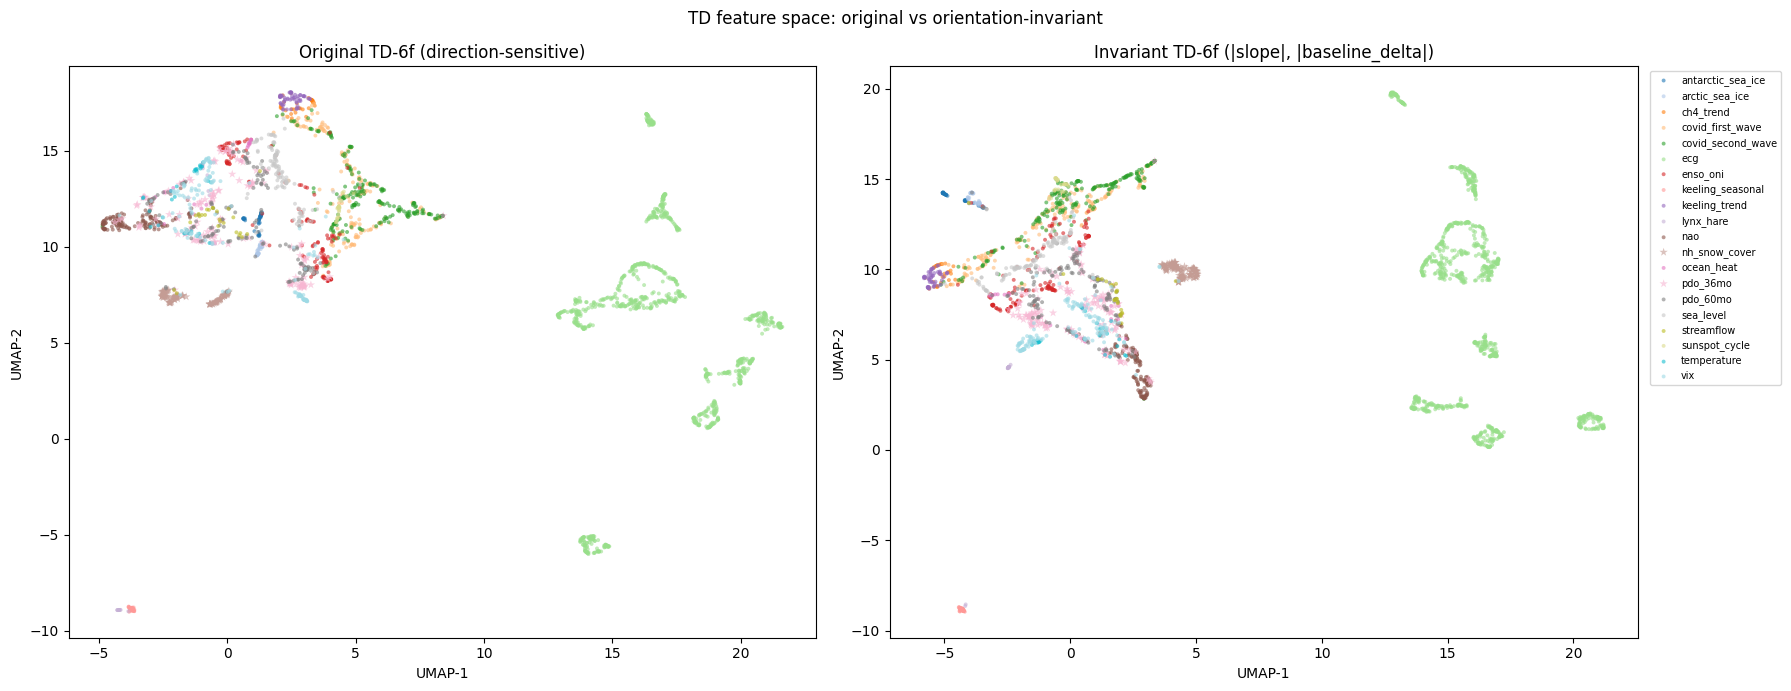

In [37]:
# ============================================================
# PART C: Orientation-invariant 6-feature fingerprint
# Replace slope + baseline_delta with their absolute values
# ============================================================
print('=== PART C: Orientation-invariant feature set ===')

# Add absolute versions
df_all['slope_abs']          = df_all['slope'].abs()
df_all['baseline_delta_abs'] = df_all['baseline_delta'].abs()

# Standard clustering on original TD-6f
X_orig = StandardScaler().fit_transform(df_all[TIMEDOM_COLS].values)
cl_orig = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5).fit_predict(X_orig)

# Clustering on orientation-invariant TD-6f
X_inv  = StandardScaler().fit_transform(df_all[TIMEDOM_INV].values)
cl_inv  = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=5).fit_predict(X_inv)

from sklearn.metrics import adjusted_rand_score

n_orig = len(set(cl_orig)) - (1 if -1 in cl_orig else 0)
n_inv  = len(set(cl_inv))  - (1 if -1 in cl_inv  else 0)
print(f'Original TD-6f:  {n_orig} clusters, {(cl_orig==-1).sum()} noise')
print(f'Invariant TD-6f: {n_inv} clusters, {(cl_inv==-1).sum()} noise')
print(f'ARI (orig vs inv): {adjusted_rand_score(cl_orig, cl_inv):.3f}')

print()
print('Cluster membership — key directional classes (original vs invariant):')
print(f'{"Dataset":25s}  {"orig cl":>8s}  {"inv cl":>8s}  {"merged?"}' )
for ds in ['keeling_trend','ch4_trend','sea_level','ocean_heat',
           'arctic_sea_ice','antarctic_sea_ice','nh_snow_cover',
           'keeling_seasonal','temperature','enso_oni','vix']:
    m = ds_labels == ds
    if not m.any(): continue
    dom_orig = max(set(cl_orig[m]), key=lambda c: (cl_orig[m]==c).sum())
    dom_inv  = max(set(cl_inv[m]),  key=lambda c: (cl_inv[m]==c).sum())
    frac_o   = (cl_orig[m]==dom_orig).sum()/m.sum()
    frac_i   = (cl_inv[m]==dom_inv).sum()/m.sum()
    print(f'{ds:25s}  cl{dom_orig:3d} {frac_o:.0%}  cl{dom_inv:3d} {frac_i:.0%}')

print()
print('UMAP of orientation-invariant features:')
reducer_inv = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_inv = reducer_inv.fit_transform(X_inv)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
reducer_orig = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_orig = reducer_orig.fit_transform(X_orig)
for ax, emb, cl, title in [
    (axes[0], emb_orig, cl_orig, 'Original TD-6f (direction-sensitive)'),
    (axes[1], emb_inv,  cl_inv,  'Invariant TD-6f (|slope|, |baseline_delta|)'),
]:
    for ds in DATASETS:
        m = ds_labels == ds
        marker = '*' if ds in PHASE_NB24 else 'o'
        ax.scatter(emb[m,0], emb[m,1], c=[palette[ds]], s=8 if marker=='o' else 40,
                   alpha=0.6, marker=marker, edgecolors='none', label=ds)
    ax.set_title(title); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
axes[1].legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)
plt.suptitle('TD feature space: original vs orientation-invariant')
plt.tight_layout()
plt.show()

---
## Findings — Notebook 24

### Finding 61 (A): PDO window-length migration

**Prediction:** PDO at 36-month windows moves closer to ENSO in Chronos space than PDO at 60-month windows.

**Result:** *(run to find out)*

**Interpretation key:** If pdo_36mo↔enso distance < pdo_60mo↔enso distance, the timescale-determines-class hypothesis (Finding 60) is confirmed. If not, PDO is structurally distinct from ENSO regardless of window length.

---

### Finding 62 (B): NH Snow Cover — declining oscillator or seasonal?

**Prediction:** Snow cover joins cl0 (Arctic/Antarctic) as a third declining oscillator member.

**Result:** *(run to find out)*

**Interpretation key:** Snow cover has the annual cycle but its long-term trend is ambiguous (spring decline documented but autumn/winter recovery partially offsetting). If it joins keeling_seasonal rather than cl0, the annual cycle dominates the trend in Chronos's view.

---

### Finding 63 (C): Effect of orientation-invariant features on class count

**Prediction:** Removing directional information collapses directionally-defined classes into pairs, reducing class count from ~8 to ~5–6.

**Result:** *(run to find out)*

**Interpretation key:** If trend and reversed-trend collapse, that confirms slope/baseline_delta are the only distinguishing features between these classes. If they stay separate, there are other features (kurtosis, lag1) that also differ.